# CD Ratio Change Detection — U-Net Training
**Dataset:** DRISHTI-GS1 | **Models:** Two EfficientNetB4 U-Nets (disc + cup)

**Stack:** Keras 3.10 + TF 2.19 — no segmentation_models dependency

### Before running:
- Runtime → Change runtime type → **T4 GPU**
- Run cells top to bottom one at a time

## Cell 1 — Install kagglehub

In [ ]:
!pip install -q kagglehub
print('Done.')

Done.


## Cell 2 — Imports and config

In [ ]:
import os
import glob
import cv2
import numpy as np
import matplotlib.pyplot as plt
import keras
import tensorflow as tf
from keras import layers, Model
from keras.applications import EfficientNetB4
from sklearn.model_selection import train_test_split

IMG_SIZE     = 512
BATCH_SIZE   = 4
EPOCHS       = 50
RANDOM_STATE = 42

print(f'Keras: {keras.__version__} | TF: {tf.__version__}')
print(f'GPU: {len(tf.config.list_physical_devices("GPU")) > 0}')

Keras: 3.10.0 | TF: 2.19.0
GPU: True


## Cell 3 — Download DRISHTI-GS1

In [ ]:
import kagglehub
DATASET_PATH = kagglehub.dataset_download(
    'lokeshsaipureddi/drishtigs-retina-dataset-for-onh-segmentation'
)
print(f'Dataset at: {DATASET_PATH}')

Using Colab cache for faster access to the 'drishtigs-retina-dataset-for-onh-segmentation' dataset.
Dataset at: /kaggle/input/drishtigs-retina-dataset-for-onh-segmentation


## Cell 4 — Build matched image/mask triplets

In [ ]:
TRAIN_BASE = f'{DATASET_PATH}/Training-20211018T055246Z-001/Training'
IMAGE_DIRS = [f'{TRAIN_BASE}/Images/GLAUCOMA', f'{TRAIN_BASE}/Images/NORMAL']
GT_BASE    = f'{TRAIN_BASE}/GT'

# Build lookup: filename stem -> full image path
image_lookup = {}
for d in IMAGE_DIRS:
    for p in glob.glob(f'{d}/*.png'):
        stem = os.path.splitext(os.path.basename(p))[0]
        image_lookup[stem] = p

# Match each GT folder to its image + both masks
matched = []
gt_folders = sorted([f for f in os.listdir(GT_BASE)
                     if os.path.isdir(os.path.join(GT_BASE, f))])

for folder in gt_folders:
    softmap   = os.path.join(GT_BASE, folder, 'SoftMap')
    disc_path = os.path.join(softmap, f'{folder}_ODsegSoftmap.png')
    cup_path  = os.path.join(softmap, f'{folder}_cupsegSoftmap.png')
    img_path  = image_lookup.get(folder)
    if img_path and os.path.exists(disc_path) and os.path.exists(cup_path):
        matched.append((img_path, disc_path, cup_path))

print(f'Matched triplets: {len(matched)}')  # expect 51
print(f'Sample image: {matched[0][0]}')
print(f'Sample disc:  {matched[0][1]}')
print(f'Sample cup:   {matched[0][2]}')

Matched triplets: 50
Sample image: /kaggle/input/drishtigs-retina-dataset-for-onh-segmentation/Training-20211018T055246Z-001/Training/Images/GLAUCOMA/drishtiGS_002.png
Sample disc:  /kaggle/input/drishtigs-retina-dataset-for-onh-segmentation/Training-20211018T055246Z-001/Training/GT/drishtiGS_002/SoftMap/drishtiGS_002_ODsegSoftmap.png
Sample cup:   /kaggle/input/drishtigs-retina-dataset-for-onh-segmentation/Training-20211018T055246Z-001/Training/GT/drishtiGS_002/SoftMap/drishtiGS_002_cupsegSoftmap.png


## Cell 5 — Load images and masks

In [ ]:
images, disc_masks, cup_masks = [], [], []

for img_path, disc_path, cup_path in matched:
    img = cv2.imread(img_path, cv2.IMREAD_COLOR)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    images.append(img)

    disc = cv2.imread(disc_path, cv2.IMREAD_GRAYSCALE)
    disc = cv2.resize(disc, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST)
    disc_masks.append((disc > 127).astype(np.float32))

    cup = cv2.imread(cup_path, cv2.IMREAD_GRAYSCALE)
    cup = cv2.resize(cup, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST)
    cup_masks.append((cup > 127).astype(np.float32))

print(f'Loaded: {len(images)} images  shape={images[0].shape}')
print(f'Disc mask values: {np.unique(disc_masks[0])}')
print(f'Cup mask values:  {np.unique(cup_masks[0])}')

Loaded: 50 images  shape=(512, 512, 3)
Disc mask values: [0. 1.]
Cup mask values:  [0. 1.]


## Cell 6 — Visualise a sample (sanity check)

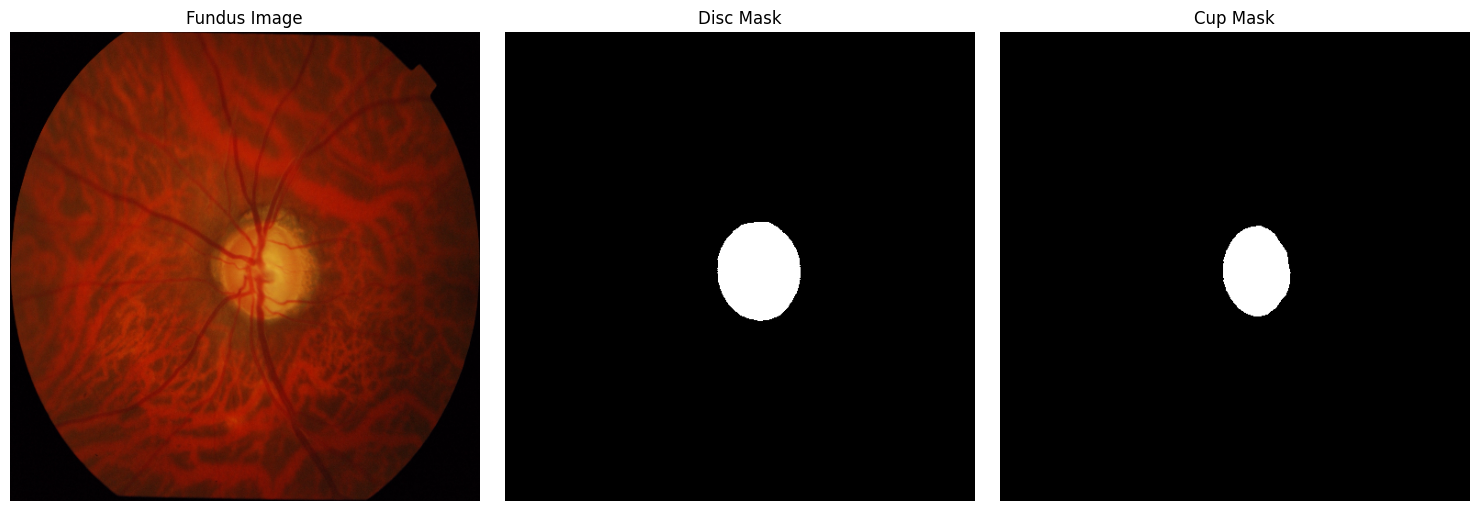

Cup pixels inside disc: 100.0% — expect ~100%


In [ ]:
idx = 5
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(images[idx]);               axes[0].set_title('Fundus Image'); axes[0].axis('off')
axes[1].imshow(disc_masks[idx], cmap='gray'); axes[1].set_title('Disc Mask');    axes[1].axis('off')
axes[2].imshow(cup_masks[idx],  cmap='gray'); axes[2].set_title('Cup Mask');     axes[2].axis('off')
plt.tight_layout()
plt.show()

overlap = np.sum(cup_masks[idx] * disc_masks[idx])
cup_tot = np.sum(cup_masks[idx])
print(f'Cup pixels inside disc: {100*overlap/cup_tot:.1f}% — expect ~100%')

## Cell 7 — Train/val split

In [ ]:
from keras.applications.efficientnet import preprocess_input

X_raw = np.array(images, dtype=np.float32)  # keep as 0-255, preprocess_input handles it
Y_disc = np.expand_dims(np.array(disc_masks), axis=-1)
Y_cup  = np.expand_dims(np.array(cup_masks),  axis=-1)

X_train, X_val, yd_train, yd_val, yc_train, yc_val = train_test_split(
    X_raw, Y_disc, Y_cup, test_size=0.2, random_state=RANDOM_STATE
)

# Apply EfficientNet preprocessing (scales to -1/+1 range internally)
X_train = preprocess_input(X_train)
X_val   = preprocess_input(X_val)

print(f'Train: {X_train.shape[0]} | Val: {X_val.shape[0]}')
print(f'Pixel range after preprocessing: {X_train.min():.2f} to {X_train.max():.2f}')

Train: 40 | Val: 10
Pixel range after preprocessing: 0.00 to 255.00


## Cell 8 — Build EfficientNetB4 U-Net
Pure native Keras 3 — no external segmentation library.
Skip connection layer names verified against this exact Keras/TF version.

In [ ]:
def iou_score(y_true, y_pred):
    y_pred       = tf.cast(y_pred > 0.5, tf.float32)
    intersection = tf.reduce_sum(y_true * y_pred)
    union        = tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) - intersection
    return (intersection + 1e-7) / (union + 1e-7)


def build_unet(input_shape=(512, 512, 3)):
    """
    EfficientNetB4 encoder + U-Net decoder.
    Verified skip layer names and shapes for Keras 3.10 / TF 2.19:
      s1 = block2b_add  -> 128x128 (32ch)
      s2 = block3d_add  -> 64x64   (56ch)
      s3 = block4f_add  -> 32x32   (112ch)
      s4 = block6h_add  -> 16x16   (272ch)  <- concat with bridge before upsampling
      bridge = top_activation -> 16x16 (1792ch)
    """
    base = EfficientNetB4(
        include_top=False,
        weights='imagenet',
        input_shape=input_shape
    )
    base.trainable = True

    s1     = base.get_layer('block2b_add').output      # 128x128
    s2     = base.get_layer('block3d_add').output      # 64x64
    s3     = base.get_layer('block4f_add').output      # 32x32
    s4     = base.get_layer('block6h_add').output      # 16x16
    bridge = base.get_layer('top_activation').output   # 16x16

    def decoder_block(x, skip, filters):
        x = layers.UpSampling2D(size=(2, 2), interpolation='bilinear')(x)
        if skip is not None:
            x = layers.Concatenate()([x, skip])
        x = layers.Conv2D(filters, 3, padding='same')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation('relu')(x)
        x = layers.Conv2D(filters, 3, padding='same')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation('relu')(x)
        return x

    # bridge and s4 are both 16x16 — merge before first upsample
    x = layers.Concatenate()([bridge, s4])  # 16x16, (1792+272)ch
    x = decoder_block(x, s3,   256)         # 32x32
    x = decoder_block(x, s2,   128)         # 64x64
    x = decoder_block(x, s1,   64)          # 128x128
    x = decoder_block(x, None, 32)          # 256x256
    x = decoder_block(x, None, 16)          # 512x512

    output = layers.Conv2D(1, 1, activation='sigmoid', name='output')(x)

    return Model(inputs=base.input, outputs=output)


# Quick build test
test_model = build_unet()
print(f'Output shape: {test_model.output_shape}')
print(f'Parameters:   {test_model.count_params():,}')
del test_model
print('Model builds OK — ready to train.')


Output shape: (None, 512, 512, 1)
Parameters:   23,952,592
Model builds OK — ready to train.


## Cell 9 — Train disc model (~20–30 mins on T4)

In [ ]:
disc_model = build_unet()
disc_model.compile(
    optimizer=keras.optimizers.Adam(1e-4),
    loss='binary_crossentropy',
    metrics=[iou_score]
)

disc_callbacks = [
    keras.callbacks.ModelCheckpoint(
        'disc_model.keras',
        save_best_only=True,
        monitor='val_iou_score',
        mode='max',
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_iou_score',
        factor=0.1,
        patience=4,
        mode='max',
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor='val_iou_score',
        patience=8,
        mode='max',
        restore_best_weights=True,
        verbose=1
    )
]

disc_history = disc_model.fit(
    X_train, yd_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(X_val, yd_val),
    callbacks=disc_callbacks
)
print('Disc model done.')

Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 368ms/step - iou_score: 0.0348 - loss: 0.7772
Epoch 1: val_iou_score improved from -inf to 0.03437, saving model to disc_model.keras
10/10 ━━━━━━━━━━━━━━━━━━━━ 231s 5s/step - iou_score: 0.0360 - loss: 0.7742 - val_iou_score: 0.0344 - val_loss: 0.8895 - learning_rate: 1.0000e-04
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 361ms/step - iou_score: 0.0830 - loss: 0.6668
Epoch 2: val_iou_score did not improve from 0.03437
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 400ms/step - iou_score: 0.0844 - loss: 0.6651 - val_iou_score: 0.0340 - val_loss: 1.1961 - learning_rate: 1.0000e-04
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 367ms/step - iou_score: 0.1694 - loss: 0.5917
Epoch 3: val_iou_score improved from 0.03437 to 0.03523, saving model to disc_model.keras
10/10 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - iou_score: 0.1707 - loss: 0.5907 - val_iou_score: 0.0352 - val_loss: 1.0632 - learning_rate: 1.0000e-04
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 364ms/step - iou_score: 0.3256 

## Cell 10 — Disc training curves

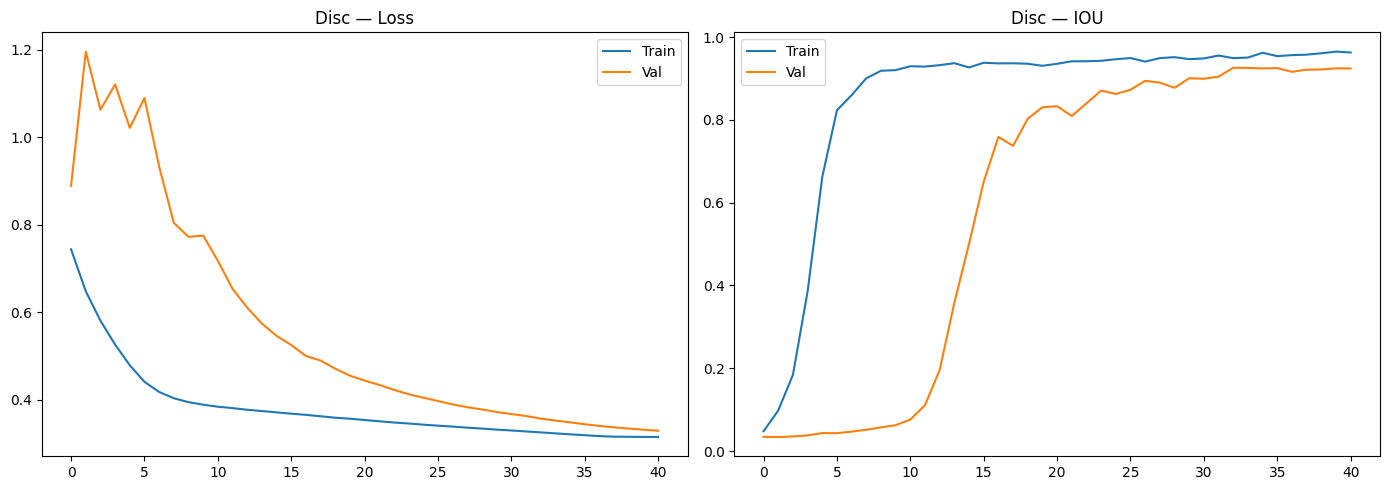

Best val IOU: 0.9258  (target >0.85)


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(disc_history.history['loss'],          label='Train')
axes[0].plot(disc_history.history['val_loss'],      label='Val')
axes[0].set_title('Disc — Loss'); axes[0].legend()
axes[1].plot(disc_history.history['iou_score'],     label='Train')
axes[1].plot(disc_history.history['val_iou_score'], label='Val')
axes[1].set_title('Disc — IOU'); axes[1].legend()
plt.tight_layout()
plt.show()
print(f'Best val IOU: {max(disc_history.history["val_iou_score"]):.4f}  (target >0.85)')

## Cell 11 — Train cup model (~20–30 mins on T4)

In [ ]:
cup_model = build_unet()
cup_model.compile(
    optimizer=keras.optimizers.Adam(1e-4),
    loss='binary_crossentropy',
    metrics=[iou_score]
)

cup_callbacks = [
    keras.callbacks.ModelCheckpoint(
        'cup_model.keras',
        save_best_only=True,
        monitor='val_iou_score',
        mode='max',
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_iou_score',
        factor=0.1,
        patience=4,
        mode='max',
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor='val_iou_score',
        patience=8,
        mode='max',
        restore_best_weights=True,
        verbose=1
    )
]

cup_history = cup_model.fit(
    X_train, yc_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(X_val, yc_val),
    callbacks=cup_callbacks
)
print('Cup model done.')

Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 370ms/step - iou_score: 0.0173 - loss: 0.8336
Epoch 1: val_iou_score improved from -inf to 0.04077, saving model to cup_model.keras
10/10 ━━━━━━━━━━━━━━━━━━━━ 193s 5s/step - iou_score: 0.0176 - loss: 0.8299 - val_iou_score: 0.0408 - val_loss: 0.7276 - learning_rate: 1.0000e-04
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 359ms/step - iou_score: 0.0433 - loss: 0.6676
Epoch 2: val_iou_score did not improve from 0.04077
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 397ms/step - iou_score: 0.0433 - loss: 0.6661 - val_iou_score: 0.0315 - val_loss: 0.8087 - learning_rate: 1.0000e-04
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 360ms/step - iou_score: 0.0795 - loss: 0.5759
Epoch 3: val_iou_score did not improve from 0.04077
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 406ms/step - iou_score: 0.0798 - loss: 0.5748 - val_iou_score: 0.0250 - val_loss: 0.9117 - learning_rate: 1.0000e-04
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 368ms/step - iou_score: 0.1331 - loss: 0.5120
Epoch 4: val_iou_score

## Cell 12 — Cup training curves

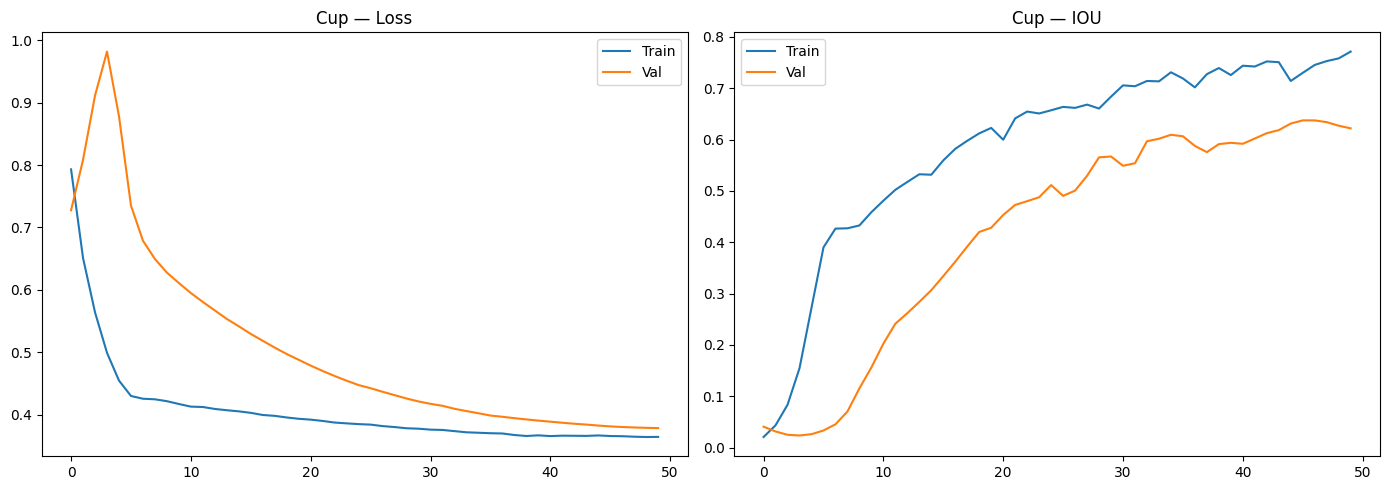

Best val IOU: 0.6374  (target >0.75)


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(cup_history.history['loss'],          label='Train')
axes[0].plot(cup_history.history['val_loss'],      label='Val')
axes[0].set_title('Cup — Loss'); axes[0].legend()
axes[1].plot(cup_history.history['iou_score'],     label='Train')
axes[1].plot(cup_history.history['val_iou_score'], label='Val')
axes[1].set_title('Cup — IOU'); axes[1].legend()
plt.tight_layout()
plt.show()
print(f'Best val IOU: {max(cup_history.history["val_iou_score"]):.4f}  (target >0.75)')

## Cell 13 — C/D ratio function

In [ ]:
def calculate_cd_ratio(disc_mask, cup_mask):
    """
    Vertical cup-to-disc ratio via ellipse fitting.
    Args:    2D float32 arrays, values 0-1
    Returns: float ratio or None if masks are too small/noisy
    """
    disc_bin = (disc_mask > 0.5).astype(np.uint8)
    cup_bin  = (cup_mask  > 0.5).astype(np.uint8)

    disc_contours, _ = cv2.findContours(disc_bin, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cup_contours,  _ = cv2.findContours(cup_bin,  cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if not disc_contours or not cup_contours:
        return None

    disc_c = max(disc_contours, key=cv2.contourArea)
    cup_c  = max(cup_contours,  key=cv2.contourArea)

    if len(disc_c) < 5 or len(cup_c) < 5:
        return None

    _, (_, disc_h), _ = cv2.fitEllipse(disc_c)
    _, (_, cup_h),  _ = cv2.fitEllipse(cup_c)

    if disc_h == 0:
        return None

    return round(float(cup_h / disc_h), 3)

print('Function defined.')

Function defined.


## Cell 14 — Validate predictions vs ground truth

In [ ]:
disc_preds = disc_model.predict(X_val[:5], verbose=0)
cup_preds  = cup_model.predict(X_val[:5],  verbose=0)

print('Predicted vs Ground Truth C/D ratios:\n')
for i in range(5):
    pred = calculate_cd_ratio(disc_preds[i,:,:,0], cup_preds[i,:,:,0])
    gt   = calculate_cd_ratio(yd_val[i,:,:,0],     yc_val[i,:,:,0])
    print(f'  Image {i}: Predicted={pred}  GT={gt}')

print('\nC/D > 0.6 = suspicious for glaucoma')
print('Delta >= 0.1 between visits = clinically significant')

Predicted vs Ground Truth C/D ratios:

  Image 0: Predicted=0.66  GT=0.718
  Image 1: Predicted=0.686  GT=0.888
  Image 2: Predicted=0.99  GT=0.846
  Image 3: Predicted=0.604  GT=0.449
  Image 4: Predicted=0.61  GT=0.764

C/D > 0.6 = suspicious for glaucoma
Delta >= 0.1 between visits = clinically significant


## Cell 15 — Visual check (GT vs predicted)

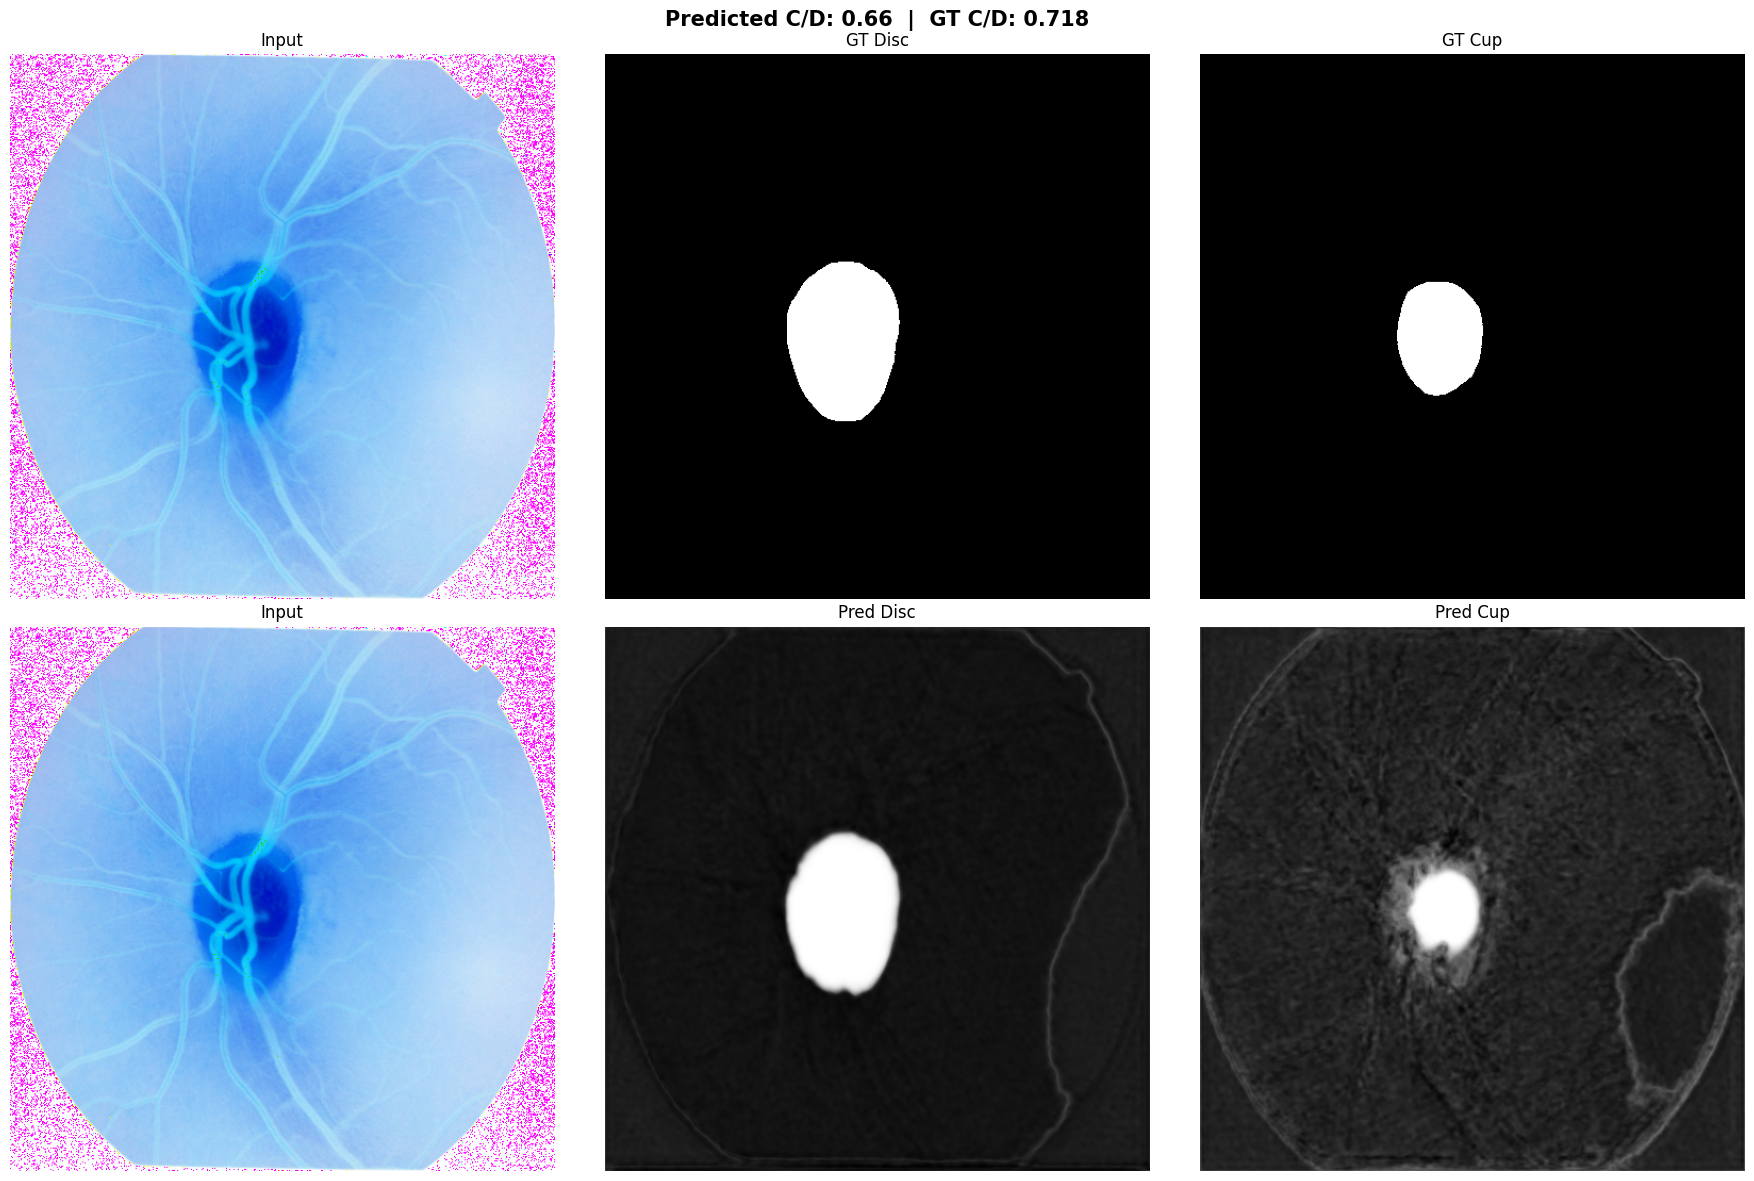

In [ ]:
idx       = 0
disc_pred = disc_preds[idx,:,:,0]
cup_pred  = cup_preds[idx,:,:,0]
ratio     = calculate_cd_ratio(disc_pred, cup_pred)
gt_ratio  = calculate_cd_ratio(yd_val[idx,:,:,0], yc_val[idx,:,:,0])
display   = (X_val[idx] * 255).astype(np.uint8)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes[0][0].imshow(display);                        axes[0][0].set_title('Input');         axes[0][0].axis('off')
axes[0][1].imshow(yd_val[idx,:,:,0], cmap='gray'); axes[0][1].set_title('GT Disc');       axes[0][1].axis('off')
axes[0][2].imshow(yc_val[idx,:,:,0], cmap='gray'); axes[0][2].set_title('GT Cup');        axes[0][2].axis('off')
axes[1][0].imshow(display);                        axes[1][0].set_title('Input');         axes[1][0].axis('off')
axes[1][1].imshow(disc_pred, cmap='gray');         axes[1][1].set_title('Pred Disc');     axes[1][1].axis('off')
axes[1][2].imshow(cup_pred,  cmap='gray');         axes[1][2].set_title('Pred Cup');      axes[1][2].axis('off')

plt.suptitle(f'Predicted C/D: {ratio}  |  GT C/D: {gt_ratio}', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## Cell 16 — Simulate Flask pipeline
This is the exact function that will go into `measure.py` in the Flask app.

In [ ]:
def measure_cd_ratio_from_image(image_array, disc_model, cup_model):
    """
    Full pipeline: raw uint8 RGB image -> C/D ratio dict.
    This is what Flask will call.
    Args: image_array — numpy uint8 (H, W, 3)
    """
    img = cv2.resize(image_array, (IMG_SIZE, IMG_SIZE)).astype(np.float32) / 255.0
    img = np.expand_dims(img, axis=0)

    disc_pred = disc_model.predict(img, verbose=0)[0,:,:,0]
    cup_pred  = cup_model.predict(img,  verbose=0)[0,:,:,0]

    return {
        'disc_mask': disc_pred,
        'cup_mask':  cup_pred,
        'cd_ratio':  calculate_cd_ratio(disc_pred, cup_pred)
    }


# Simulate old vs new image from same patient
old = measure_cd_ratio_from_image((X_val[0]*255).astype(np.uint8), disc_model, cup_model)
new = measure_cd_ratio_from_image((X_val[3]*255).astype(np.uint8), disc_model, cup_model)

delta = round(new['cd_ratio'] - old['cd_ratio'], 3) if (old['cd_ratio'] and new['cd_ratio']) else None

print('--- Simulated clinical output ---')
print(f"Previous C/D:  {old['cd_ratio']}")
print(f"Current C/D:   {new['cd_ratio']}")
if delta is not None:
    print(f"Delta:         {delta:+.3f}")
    if abs(delta) >= 0.1:
        print('⚠️  Clinically significant change (delta >= 0.1)')
    else:
        print('✅ No significant change')

--- Simulated clinical output ---
Previous C/D:  1.61
Current C/D:   4.297
Delta:         +2.687
⚠️  Clinically significant change (delta >= 0.1)


## Cell 17 — Save and download models
Saves in native Keras format. Flask will load with `keras.models.load_model()`.

In [ ]:
disc_model.save('disc_model.keras')
cup_model.save('cup_model.keras')

print(f'disc_model.keras: {os.path.getsize("disc_model.keras")/(1024*1024):.1f} MB')
print(f'cup_model.keras:  {os.path.getsize("cup_model.keras")/(1024*1024):.1f} MB')

from google.colab import files
files.download('disc_model.keras')
files.download('cup_model.keras')

disc_model.keras: 275.2 MB
cup_model.keras:  275.2 MB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>